## 0. 配置区

In [42]:
# ── 配置 ──────────────────────────────────────────────────
from pathlib import Path

# 数据集名称列表（对应 FiftyOne 中已存在的数据集）
DATASET_NAME_LIST = [
    # "TESTsahi_null_run_whole_rawData_good3_v1_air2_0701_0823",
    "TESTms2_0605_0923",
    # "TESTsahi_null_run_whole_rawData_good3_v1_southfarm2_0712_0823",
]

# 输出目录（同 notebook 所在目录）
OUTPUT_PATH = Path("/home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/00_pipeline/a01_image_clarity_evaluation")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# 网格参数：将 4656×3496 图像切分为 9 列 × 7 行
GRID_ROWS = 7
GRID_COLS = 9

# 中心目标区域行范围（0-indexed, exclusive end）
# 7 行中的中间 3 行 = 第 2、3、4 行
ROI_ROW_START = 2
ROI_ROW_END   = 5   # exclusive，即取 heatmap[2:5, :]

# 参与计算的算法列表
ALGO_LIST = ["laplacian", "sobel", "tenengrad", "brenner", "variance"]

# CSV 输出路径
CSV_OUTPUT_PATH = OUTPUT_PATH / "clarity_summary.csv"

## 1. 初始化日志

In [43]:
import logging

try:
    import ipynbname
    _nb_name = ipynbname.name()
except Exception:
    _nb_name = "image_clarity_evaluation"

log_file_name = OUTPUT_PATH / f"{_nb_name}.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler(log_file_name, encoding="utf-8"),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)
logger.info("日志初始化完成，开始执行清晰度评估流程")

2026-02-23 18:37:13,545 [INFO] 日志初始化完成，开始执行清晰度评估流程


## 2. 算法函数定义

### Laplacian 方差

In [44]:
import cv2
import numpy as np


def _laplacian_var(patch_gray: np.ndarray) -> float:
    """拉普拉斯方差，对离焦最敏感，推荐主指标"""
    return float(np.var(cv2.Laplacian(patch_gray, cv2.CV_64F)))

### Sobel 梯度能量

In [45]:
def _sobel_energy(patch_gray: np.ndarray) -> float:
    """Sobel 梯度能量，对边缘/纹理敏感"""
    grad_x = cv2.Sobel(patch_gray, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(patch_gray, cv2.CV_64F, 0, 1, ksize=3)
    return float(np.mean(grad_x ** 2 + grad_y ** 2))

### Tenengrad

In [46]:
def _tenengrad(patch_gray: np.ndarray, threshold: float = 0.0) -> float:
    """Tenengrad（带阈值 Sobel），抗噪更强"""
    grad_x = cv2.Sobel(patch_gray, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(patch_gray, cv2.CV_64F, 0, 1, ksize=3)
    gradient_magnitude_sq = grad_x ** 2 + grad_y ** 2
    mask = gradient_magnitude_sq > threshold
    return float(np.mean(gradient_magnitude_sq[mask])) if mask.any() else 0.0

### Brenner 差分

In [47]:
def _brenner(patch_gray: np.ndarray) -> float:
    """Brenner 差分，计算快，横向差分"""
    diff = patch_gray[:, 2:].astype(np.float64) - patch_gray[:, :-2].astype(np.float64)
    return float(np.sum(diff ** 2))

### 像素方差（Baseline）

In [48]:
def _variance(patch_gray: np.ndarray) -> float:
    """像素方差，Baseline 方法"""
    return float(np.var(patch_gray.astype(np.float64)))

### 网格切分调度函数

In [49]:
_ALGO_FN_MAP = {
    "laplacian": _laplacian_var,
    "sobel":     _sobel_energy,
    "tenengrad": _tenengrad,
    "brenner":   _brenner,
    "variance":  _variance,
}


def compute_raw_heatmap(
    img_gray: np.ndarray,
    grid_rows: int,
    grid_cols: int,
    algo: str,
) -> np.ndarray:
    """
    将灰度图切分为 grid_rows × grid_cols 网格，对每格计算清晰度分数。
    返回 shape=(grid_rows, grid_cols) 的 float64 ndarray。
    使用 np.array_split 自动处理余数，保证均匀分割。
    """
    fn = _ALGO_FN_MAP[algo]
    row_splits = np.array_split(img_gray, grid_rows, axis=0)
    heatmap = np.zeros((grid_rows, grid_cols), dtype=np.float64)
    for r, row_patch in enumerate(row_splits):
        col_splits = np.array_split(row_patch, grid_cols, axis=1)
        for c, patch in enumerate(col_splits):
            heatmap[r, c] = fn(patch)
    return heatmap

## Step 1：批量读图，计算各算法原始清晰度分数

In [51]:
# ── Step 1：批量读图，计算各算法原始清晰度分数 ──────────────
# 输入：FiftyOne 数据集 filepath 对应的磁盘原始图像
# 输出：raw_scores_dict[dataset_name][sample_id][algo] = ndarray(7,9)

import fiftyone as fo
from tqdm import tqdm

logger.info("Step 1 开始：批量读图计算清晰度分数")

raw_scores_dict = {}

for dataset_name in DATASET_NAME_LIST:
    dataset = fo.load_dataset(dataset_name)
    dataset_scores = {}  # sample_id → {algo → ndarray(7,9)}

    for sample in tqdm(dataset.iter_samples(), total=len(dataset), desc=f"  [{dataset_name}]"):
        img_bgr = cv2.imread(sample.filepath)
        if img_bgr is None:
            logger.warning(f"图像读取失败，跳过: {sample.filepath}")
            continue
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

        sample_algo_scores = {}
        for algo in ALGO_LIST:
            try:
                sample_algo_scores[algo] = compute_raw_heatmap(
                    img_gray, GRID_ROWS, GRID_COLS, algo
                )
            except Exception as e:
                logger.error(f"算法 {algo} 计算失败 {sample.filepath}: {e}")
        dataset_scores[sample.id] = sample_algo_scores

    raw_scores_dict[dataset_name] = dataset_scores
    logger.info(f"Step 1 [{dataset_name}] 完成，共处理 {len(dataset_scores)} 张")

total_processed = sum(len(v) for v in raw_scores_dict.values())
logger.info(f"Step 1 全部完成，3 个数据集共处理 {total_processed} 张")

2026-02-23 18:38:15,414 [INFO] Step 1 开始：批量读图计算清晰度分数
  [TESTms2_0605_0923]: 100%|██████████| 12254/12254 [54:19<00:00,  3.76it/s] 
2026-02-23 19:32:35,213 [INFO] Step 1 [TESTms2_0605_0923] 完成，共处理 12254 张
2026-02-23 19:32:35,223 [INFO] Step 1 全部完成，3 个数据集共处理 12254 张


## Step 2：按数据集 × 算法全局归一化

In [52]:
# ── Step 2：按数据集 × 算法全局归一化 ──────────────────────
# 输入：raw_scores_dict
# 输出：norm_scores_dict[dataset_name][sample_id][algo] = ndarray(7,9)，值域 [0,1]

logger.info("Step 2 开始：p1/p99 百分位截断归一化")

norm_scores_dict = {}

for dataset_name in DATASET_NAME_LIST:
    dataset_raw = raw_scores_dict[dataset_name]
    dataset_norm = {}

    for algo in ALGO_LIST:
        # 收集当前 dataset × algo 的所有格子分数
        all_values = np.concatenate([
            dataset_raw[sid][algo].ravel()
            for sid in dataset_raw
            if algo in dataset_raw[sid]
        ])
        p1  = np.percentile(all_values, 1)
        p99 = np.percentile(all_values, 99)
        scale = p99 - p1 if p99 > p1 else 1.0

        for sample_id, algo_scores in dataset_raw.items():
            if algo not in algo_scores:
                continue
            raw_heatmap  = algo_scores[algo]
            norm_heatmap = np.clip((raw_heatmap - p1) / scale, 0.0, 1.0).astype(np.float32)
            if sample_id not in dataset_norm:
                dataset_norm[sample_id] = {}
            dataset_norm[sample_id][algo] = norm_heatmap

        logger.info(f"Step 2 [{dataset_name}][{algo}] p1={p1:.4f}, p99={p99:.4f}")

    norm_scores_dict[dataset_name] = dataset_norm
    logger.info(f"Step 2 [{dataset_name}] 全部算法归一化完成，共 {len(dataset_norm)} 个样本")

logger.info("Step 2 全部完成")

2026-02-23 21:31:22,728 [INFO] Step 2 开始：p1/p99 百分位截断归一化
2026-02-23 21:31:22,840 [INFO] Step 2 [TESTms2_0605_0923][laplacian] p1=0.7057, p99=912.2548
2026-02-23 21:31:22,910 [INFO] Step 2 [TESTms2_0605_0923][sobel] p1=7.2464, p99=15805.9451
2026-02-23 21:31:22,992 [INFO] Step 2 [TESTms2_0605_0923][tenengrad] p1=17.9212, p99=16506.2688
2026-02-23 21:31:23,066 [INFO] Step 2 [TESTms2_0605_0923][brenner] p1=66150.0000, p99=98334398.6900
2026-02-23 21:31:23,145 [INFO] Step 2 [TESTms2_0605_0923][variance] p1=0.4513, p99=3939.2495
2026-02-23 21:31:23,145 [INFO] Step 2 [TESTms2_0605_0923] 全部算法归一化完成，共 12254 个样本
2026-02-23 21:31:23,146 [INFO] Step 2 全部完成


## Step 3：写入 FiftyOne Heatmap 字段

In [53]:
# ── Step 3：写入 FiftyOne Heatmap 字段 ──────────────────────
# 输入：norm_scores_dict
# 输出：FiftyOne 数据集新增 clarity_{algo} EmbeddedDocumentField(Heatmap)

logger.info("Step 3 开始：写入 FiftyOne Heatmap 字段")

for dataset_name in DATASET_NAME_LIST:
    dataset      = fo.load_dataset(dataset_name)
    dataset_norm = norm_scores_dict[dataset_name]
    schema       = dataset.get_field_schema()

    # 声明 Heatmap 字段（如不存在）
    for algo in ALGO_LIST:
        field_name = f"clarity_{algo}"
        if field_name not in schema:
            dataset.add_sample_field(
                field_name,
                fo.EmbeddedDocumentField,
                embedded_doc_type=fo.Heatmap,
            )

    # 逐样本写入归一化 heatmap
    for sample in dataset.iter_samples(autosave=True):
        if sample.id not in dataset_norm:
            continue
        sample_norm = dataset_norm[sample.id]
        for algo in ALGO_LIST:
            if algo not in sample_norm:
                continue
            sample[f"clarity_{algo}"] = fo.Heatmap(
                map=sample_norm[algo],
                range=[0.0, 1.0],
            )

    logger.info(f"Step 3 [{dataset_name}] 完成，写入 {len(dataset_norm)} 个样本的 Heatmap 字段")

logger.info("Step 3 全部完成")

2026-02-23 21:31:27,863 [INFO] Step 3 开始：写入 FiftyOne Heatmap 字段
2026-02-23 21:31:58,273 [INFO] Step 3 [TESTms2_0605_0923] 完成，写入 12254 个样本的 Heatmap 字段
2026-02-23 21:31:58,273 [INFO] Step 3 全部完成


## Step 4：计算每张图的标量汇总统计，写入 FiftyOne 浮点字段

In [54]:
# ── Step 4：计算每张图标量汇总统计，写入 FiftyOne 浮点字段 ──
# 输入：norm_scores_dict（完整 7×9 归一化 heatmap）
# 输出：FiftyOne 新增 clarity_{algo}_{mean/std/min/max} FloatField
#       统计仅基于中间 3 行（ROI_ROW_START:ROI_ROW_END = 2:5），即 3×9=27 格

from tqdm import tqdm

logger.info("Step 4 开始：写入标量汇总统计字段（仅中间 3 行 ROI，3×9=27 格）")

STAT_SUFFIXES = ["mean", "std", "min", "max"]

for dataset_name in tqdm(DATASET_NAME_LIST, desc="Processing datasets"):
    dataset      = fo.load_dataset(dataset_name)
    dataset_norm = norm_scores_dict[dataset_name]
    schema       = dataset.get_field_schema()

    # 声明浮点统计字段（如不存在）
    for algo in ALGO_LIST:
        for suffix in STAT_SUFFIXES:
            field_name = f"clarity_{algo}_{suffix}"
            if field_name not in schema:
                dataset.add_sample_field(field_name, fo.FloatField)

    # 逐样本计算并写入（只取中间 3 行 ROI 子区域）
    for sample in tqdm(dataset.iter_samples(autosave=True), total=len(dataset), desc=f"  [{dataset_name}]"):
        if sample.id not in dataset_norm:
            continue
        sample_norm = dataset_norm[sample.id]
        for algo in ALGO_LIST:
            if algo not in sample_norm:
                continue
            heatmap = sample_norm[algo][ROI_ROW_START:ROI_ROW_END, :]
            sample[f"clarity_{algo}_mean"] = float(np.mean(heatmap))
            sample[f"clarity_{algo}_std"]  = float(np.std(heatmap))
            sample[f"clarity_{algo}_min"]  = float(np.min(heatmap))
            sample[f"clarity_{algo}_max"]  = float(np.max(heatmap))

    logger.info(f"Step 4 [{dataset_name}] 完成，写入 {len(dataset_norm)} 个样本的统计字段（ROI 中间 3 行）")

logger.info("Step 4 全部完成")

2026-02-23 21:31:58,279 [INFO] Step 4 开始：写入标量汇总统计字段（仅中间 3 行 ROI，3×9=27 格）
  [TESTms2_0605_0923]: 100%|██████████| 12254/12254 [00:24<00:00, 492.56it/s]
2026-02-23 21:32:23,162 [INFO] Step 4 [TESTms2_0605_0923] 完成，写入 12254 个样本的统计字段（ROI 中间 3 行）
Processing datasets: 100%|██████████| 1/1 [00:24<00:00, 24.88s/it]
2026-02-23 21:32:23,162 [INFO] Step 4 全部完成


## Step 5：全局空间平均热图（Aggregate Heatmap）

2026-02-23 21:32:23,168 [INFO] Step 5 开始：计算全局平均热图


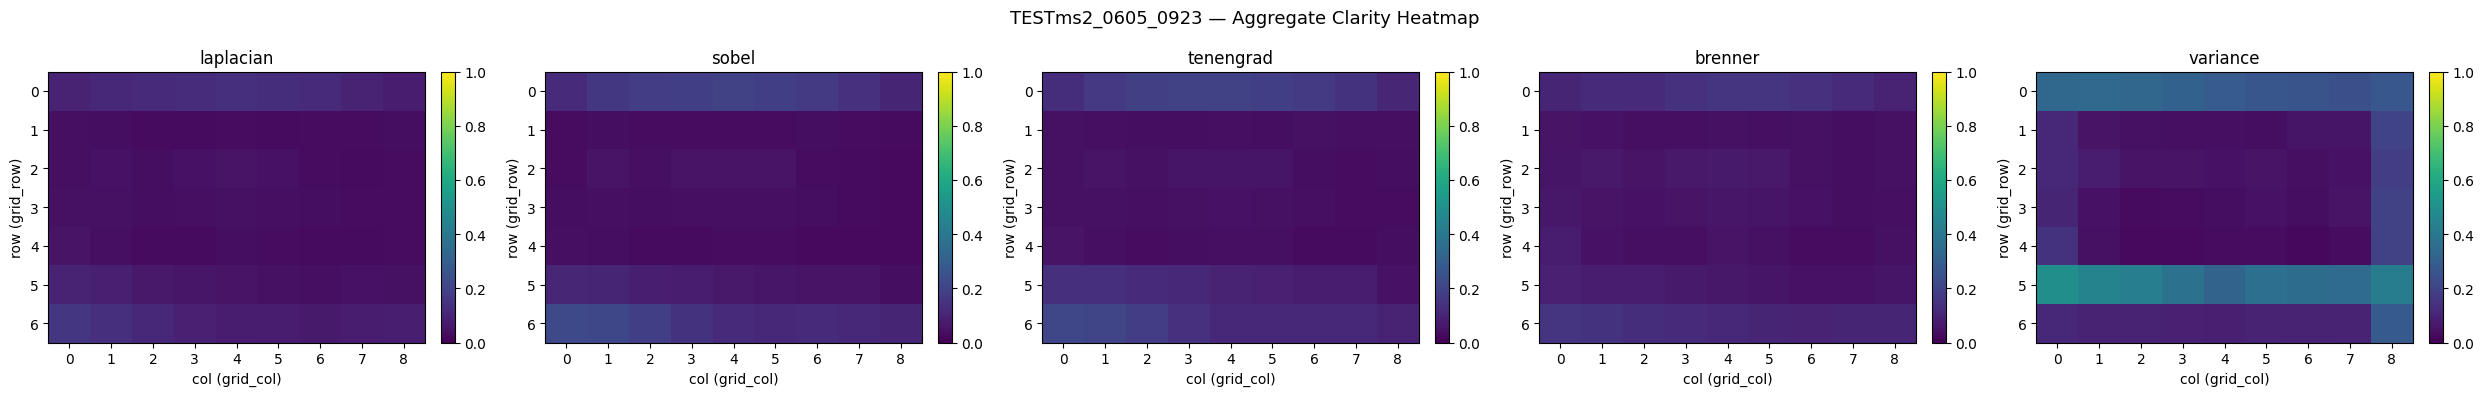

2026-02-23 21:32:23,532 [INFO] Step 5 [TESTms2_0605_0923] 完成，已保存 5 个 .npy 文件
2026-02-23 21:32:23,533 [INFO] Step 5 全部完成


In [55]:
# ── Step 5：全局空间平均热图 ────────────────────────────────
# 输入：norm_scores_dict
# 输出：aggregate_heatmap_{dataset}_{algo}.npy + matplotlib 可视化

import matplotlib.pyplot as plt
import matplotlib
from IPython.display import display

matplotlib.rcParams["font.family"] = "DejaVu Sans"

logger.info("Step 5 开始：计算全局平均热图")

for dataset_name in DATASET_NAME_LIST:
    dataset_norm = norm_scores_dict[dataset_name]
    fig, axes = plt.subplots(1, len(ALGO_LIST), figsize=(5 * len(ALGO_LIST), 4))
    fig.suptitle(f"{dataset_name} — Aggregate Clarity Heatmap", fontsize=13)

    for col_idx, algo in enumerate(ALGO_LIST):
        heatmaps = [
            dataset_norm[sid][algo]
            for sid in dataset_norm
            if algo in dataset_norm[sid]
        ]
        agg_heatmap = np.mean(heatmaps, axis=0).astype(np.float32)

        npy_path = OUTPUT_PATH / f"aggregate_heatmap_{dataset_name}_{algo}.npy"
        np.save(npy_path, agg_heatmap)

        ax = axes[col_idx]
        im = ax.imshow(agg_heatmap, vmin=0, vmax=1, cmap="viridis", aspect="auto")
        ax.set_title(algo)
        ax.set_xlabel("col (grid_col)")
        ax.set_ylabel("row (grid_row)")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    display(fig)
    plt.close(fig)
    logger.info(f"Step 5 [{dataset_name}] 完成，已保存 {len(ALGO_LIST)} 个 .npy 文件")

logger.info("Step 5 全部完成")

## Step 6：导出 CSV 供相关性分析

In [56]:
# ── Step 6：导出 CSV 供相关性分析 ────────────────────────────
# 输入：FiftyOne 数据集（clarity_* 字段 + datetime + focus）
# 输出：clarity_summary.csv

import pandas as pd
from tqdm import tqdm

logger.info("Step 6 开始：导出相关性分析 CSV")

rows = []

for dataset_name in tqdm(DATASET_NAME_LIST, desc="Exporting datasets"):
    dataset = fo.load_dataset(dataset_name)

    for sample in tqdm(dataset.iter_samples(), total=len(dataset), desc=f"  [{dataset_name}]"):
        row = {
            "filepath":     sample.filepath,
            "dataset_name": dataset_name,
            "datetime":     getattr(sample, "datetime", None),
            "focus":        getattr(sample, "focus", None),
        }

        # 派生时间字段
        dt = row["datetime"]
        if dt is not None:
            row["hour"]        = dt.hour + dt.minute / 60.0
            row["date_str"]    = dt.strftime("%m%d")
            row["day_of_year"] = dt.timetuple().tm_yday
        else:
            row["hour"] = row["date_str"] = row["day_of_year"] = None

        # 写入各算法的 mean 和 std
        for algo in ALGO_LIST:
            row[f"clarity_{algo}_mean"] = getattr(sample, f"clarity_{algo}_mean", None)
            row[f"clarity_{algo}_std"]  = getattr(sample, f"clarity_{algo}_std",  None)

        rows.append(row)

    logger.info(f"Step 6 [{dataset_name}] 读取完成，当前共 {len(rows)} 行")

clarity_df = pd.DataFrame(rows)
clarity_df.to_csv(CSV_OUTPUT_PATH, index=False, encoding="utf-8-sig")

logger.info(f"Step 6 全部完成，共导出 {len(clarity_df)} 行，保存至 {CSV_OUTPUT_PATH}")

2026-02-23 21:32:23,541 [INFO] Step 6 开始：导出相关性分析 CSV
Exporting datasets:   0%|          | 0/1 [00:00<?, ?it/s]

  [TESTms2_0605_0923]: 100%|██████████| 12254/12254 [00:13<00:00, 917.52it/s] 
2026-02-23 21:32:36,919 [INFO] Step 6 [TESTms2_0605_0923] 读取完成，当前共 12254 行
Exporting datasets: 100%|██████████| 1/1 [00:13<00:00, 13.36s/it]
2026-02-23 21:32:37,085 [INFO] Step 6 全部完成，共导出 12254 行，保存至 /home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/00_pipeline/a01_image_clarity_evaluation/clarity_summary.csv


## 验证：抽查字段与 CSV 完整性

In [57]:
# ── 验证：抽查字段与 CSV 完整性 ──────────────────────────────
from IPython.display import display, HTML

# 抽查第一个数据集的第一个样本
first_dataset = fo.load_dataset(DATASET_NAME_LIST[0])
first_sample  = first_dataset.first()

display(HTML(f"<b>数据集：</b>{DATASET_NAME_LIST[0]}<br>"
             f"<b>样本 ID：</b>{first_sample.id}<br>"
             f"<b>文件路径：</b>{first_sample.filepath}"))

field_check_rows = []
for algo in ALGO_LIST:
    heatmap_field = getattr(first_sample, f"clarity_{algo}", None)
    mean_val      = getattr(first_sample, f"clarity_{algo}_mean", None)
    std_val       = getattr(first_sample, f"clarity_{algo}_std",  None)
    field_check_rows.append({
        "algo":          algo,
        "heatmap_shape": str(heatmap_field.map.shape) if heatmap_field else "None",
        "mean":          f"{mean_val:.4f}" if mean_val is not None else "None",
        "std":           f"{std_val:.4f}"  if std_val  is not None else "None",
    })

display(pd.DataFrame(field_check_rows))

# 检查 CSV
display(HTML("<b>=== clarity_summary.csv 前 5 行 ===</b>"))
df_check = pd.read_csv(CSV_OUTPUT_PATH)
display(df_check.head())
display(HTML(f"<b>CSV shape：</b>{df_check.shape}"))

nan_counts = df_check.isnull().sum()
nan_nonzero = nan_counts[nan_counts > 0]
if len(nan_nonzero) > 0:
    display(HTML("<b>含 NaN 的列：</b>"))
    display(nan_nonzero)
else:
    display(HTML("<b>所有列无 NaN，数据完整</b>"))

,algo,heatmap_shape,mean,std
0,laplacian,"(7, 9)",0.0049,0.0040
1,sobel,"(7, 9)",0.0069,0.0069
2,tenengrad,"(7, 9)",0.0100,0.0104
3,brenner,"(7, 9)",0.0087,0.0078
4,variance,"(7, 9)",0.0348,0.0322


,filepath,dataset_name,datetime,focus,hour,date_str,day_of_year,clarity_laplacian_mean,clarity_laplacian_std,clarity_sobel_mean,clarity_sobel_std,clarity_tenengrad_mean,clarity_tenengrad_std,clarity_brenner_mean,clarity_brenner_std,clarity_variance_mean,clarity_variance_std
0,/home/tianqi/D/01_Projects/01_swd/02_code/pipe...,TESTms2_0605_0923,2024-06-05 11:33:00,700,11.550000,605,157,0.004920,0.003976,0.006934,0.006871,0.010017,0.010370,0.008701,0.007755,0.034826,0.032216
1,/home/tianqi/D/01_Projects/01_swd/02_code/pipe...,TESTms2_0605_0923,2024-06-05 12:01:00,700,12.016667,605,157,0.003232,0.004184,0.003678,0.004646,0.004487,0.005428,0.004927,0.005525,0.023625,0.022678
2,/home/tianqi/D/01_Projects/01_swd/02_code/pipe...,TESTms2_0605_0923,2024-06-05 12:31:00,700,12.516667,605,157,0.002620,0.001965,0.003811,0.003503,0.005990,0.005961,0.005793,0.006671,0.027724,0.029509
3,/home/tianqi/D/01_Projects/01_swd/02_code/pipe...,TESTms2_0605_0923,2024-06-05 13:01:00,700,13.016667,605,157,0.002831,0.003668,0.003916,0.004190,0.005650,0.005617,0.005582,0.006144,0.024945,0.025119
4,/home/tianqi/D/01_Projects/01_swd/02_code/pipe...,TESTms2_0605_0923,2024-06-05 13:31:00,700,13.516667,605,157,0.001913,0.001948,0.002764,0.002690,0.004049,0.004077,0.004092,0.004434,0.024199,0.022975
